# Londres - Análise de Airbnb
## Notebook de Arthur Vinicius Machado e Mateus Batichotti Silva

Dados obtidos em [Inside Airbnb](https://insideairbnb.com/london/) e analisados com Python. O objetivo é analisar os dados de Airbnb em Londres, buscando insights sobre preços, tipos de acomodações, localização e outros fatores relevantes para entender o mercado de aluguel de curto prazo na cidade.

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

Blablabla

In [3]:
original_df = pd.read_csv("./listings.csv")

In [4]:
df = original_df[['id', 'name', 'host_id', 'host_name', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_is_superhost', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month']]

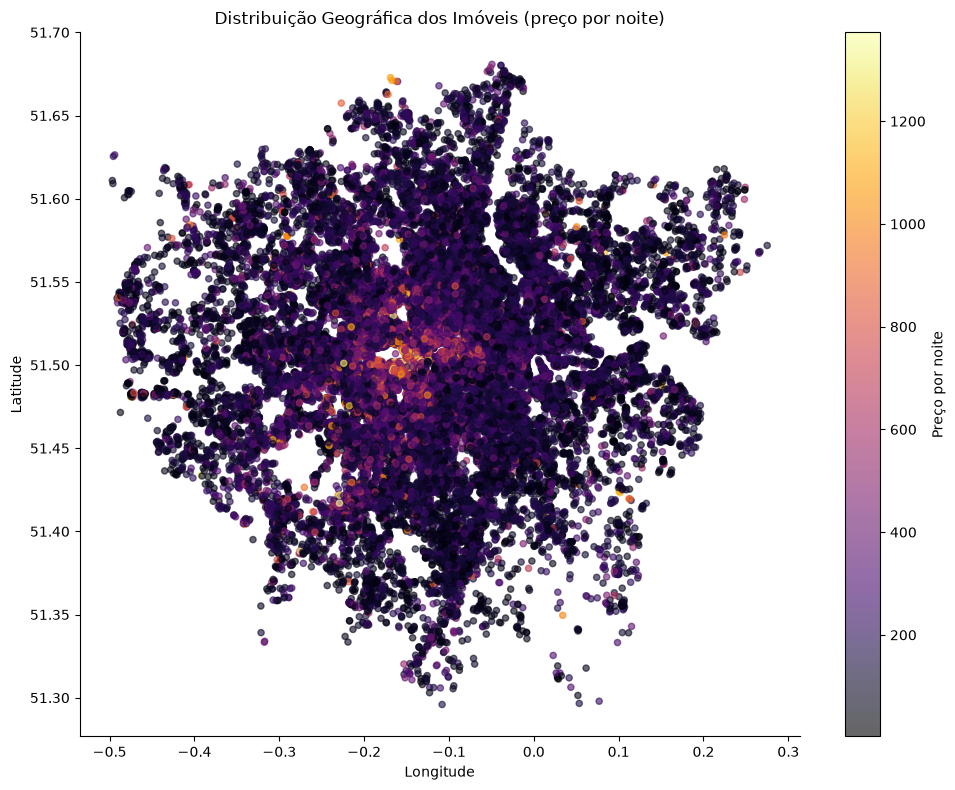

In [39]:

# Remove linhas sem preço por noite ou sem coordenadas
df_plot = df.dropna(subset=['price_quote_price_per_night', 'latitude', 'longitude']).copy()

# Remove outliers extremos (ex: acima do percentil 99)
limite = df_plot['price_quote_price_per_night'].quantile(0.99)
df_plot = df_plot[df_plot['price_quote_price_per_night'] <= limite]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df_plot['longitude'], df_plot['latitude'], c=df_plot['price_quote_price_per_night'], 
                      cmap='inferno', alpha=0.6, s=20)
plt.colorbar(scatter, label='Preço por noite')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Distribuição Geográfica dos Imóveis (preço por noite)')

# Remove bordas superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

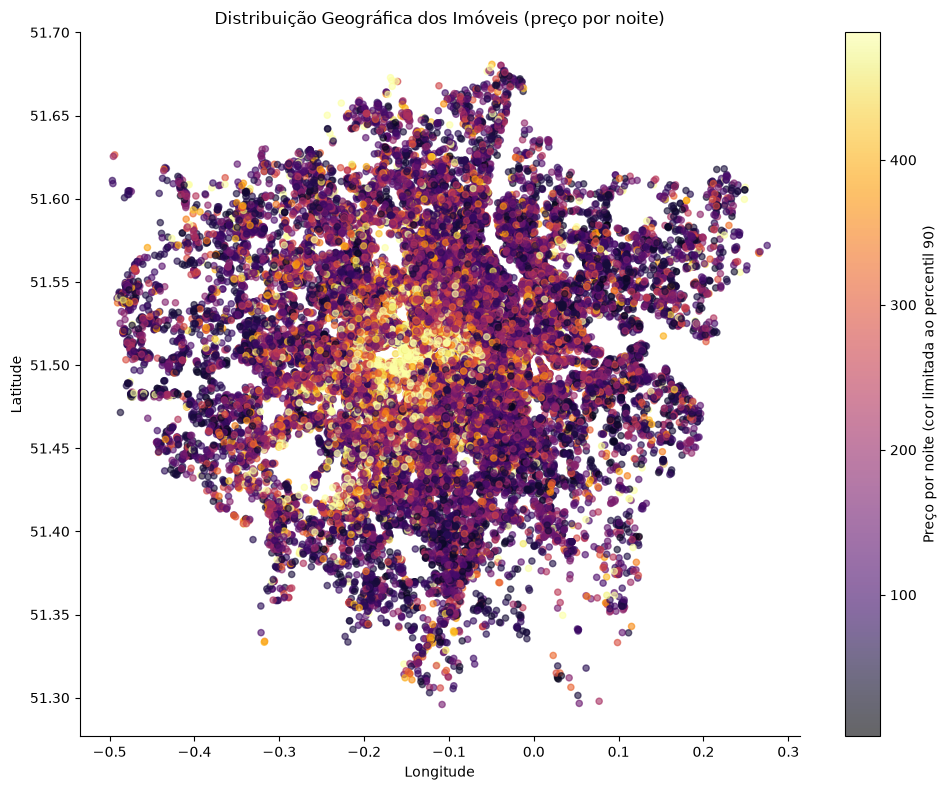

In [38]:
vmax = df_plot['price_quote_price_per_night'].quantile(0.90)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df_plot['longitude'], df_plot['latitude'], c=df_plot['price_quote_price_per_night'], 
                      cmap='inferno', alpha=0.6, s=20, vmax=vmax)
plt.colorbar(scatter, label='Preço por noite (cor limitada ao percentil 90)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Distribuição Geográfica dos Imóveis (preço por noite)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

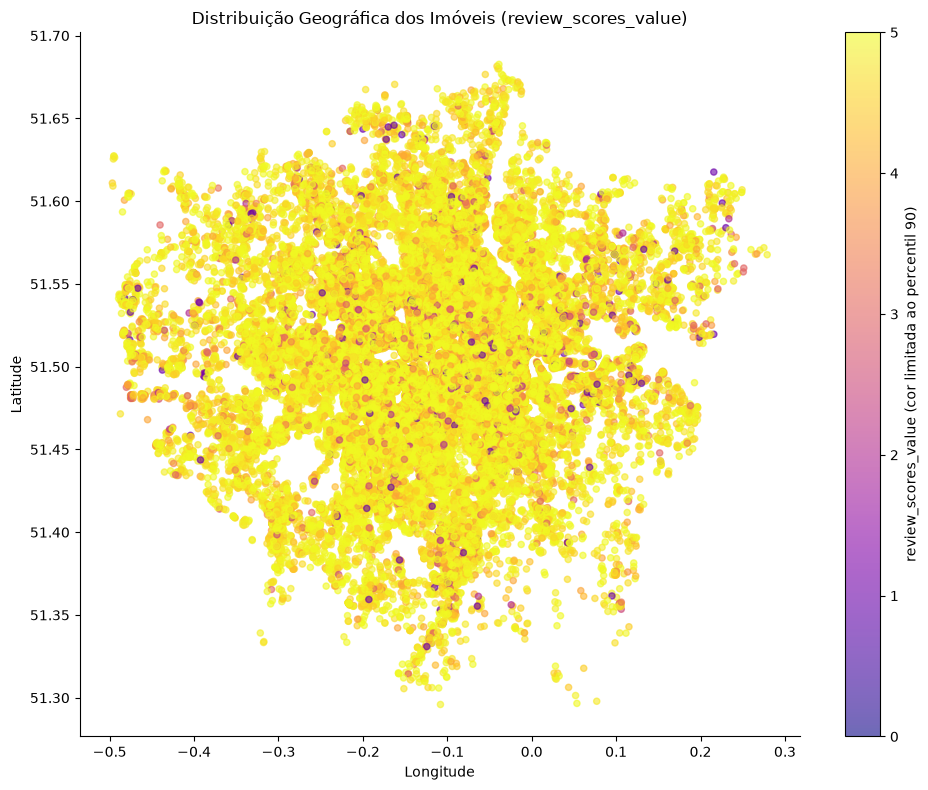

In [47]:
df_plot = df.dropna(subset=['review_scores_value', 'latitude', 'longitude']).copy()

vmax = df_plot['review_scores_value'].quantile(0.999)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df_plot['longitude'], df_plot['latitude'], c=df_plot['review_scores_value'], 
                      cmap='plasma', alpha=0.6, s=20, vmax=vmax)
plt.colorbar(scatter, label='review_scores_value (cor limitada ao percentil 90)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Distribuição Geográfica dos Imóveis (review_scores_value)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

                      Coluna 1                                    Coluna 2  Correlação  Módulo da correlação
                maximum_nights                      maximum_maximum_nights    1.000000              1.000000
                minimum_nights                      minimum_minimum_nights    1.000000              1.000000
        maximum_maximum_nights                      maximum_nights_avg_ntm    0.999999              0.999999
                maximum_nights                      maximum_nights_avg_ntm    0.999999              0.999999
calculated_host_listings_count calculated_host_listings_count_entire_homes    0.979318              0.979318
               availability_60                             availability_90    0.975003              0.975003
        minimum_minimum_nights                      minimum_nights_avg_ntm    0.935986              0.935986
                minimum_nights                      minimum_nights_avg_ntm    0.935986              0.935986
               avai

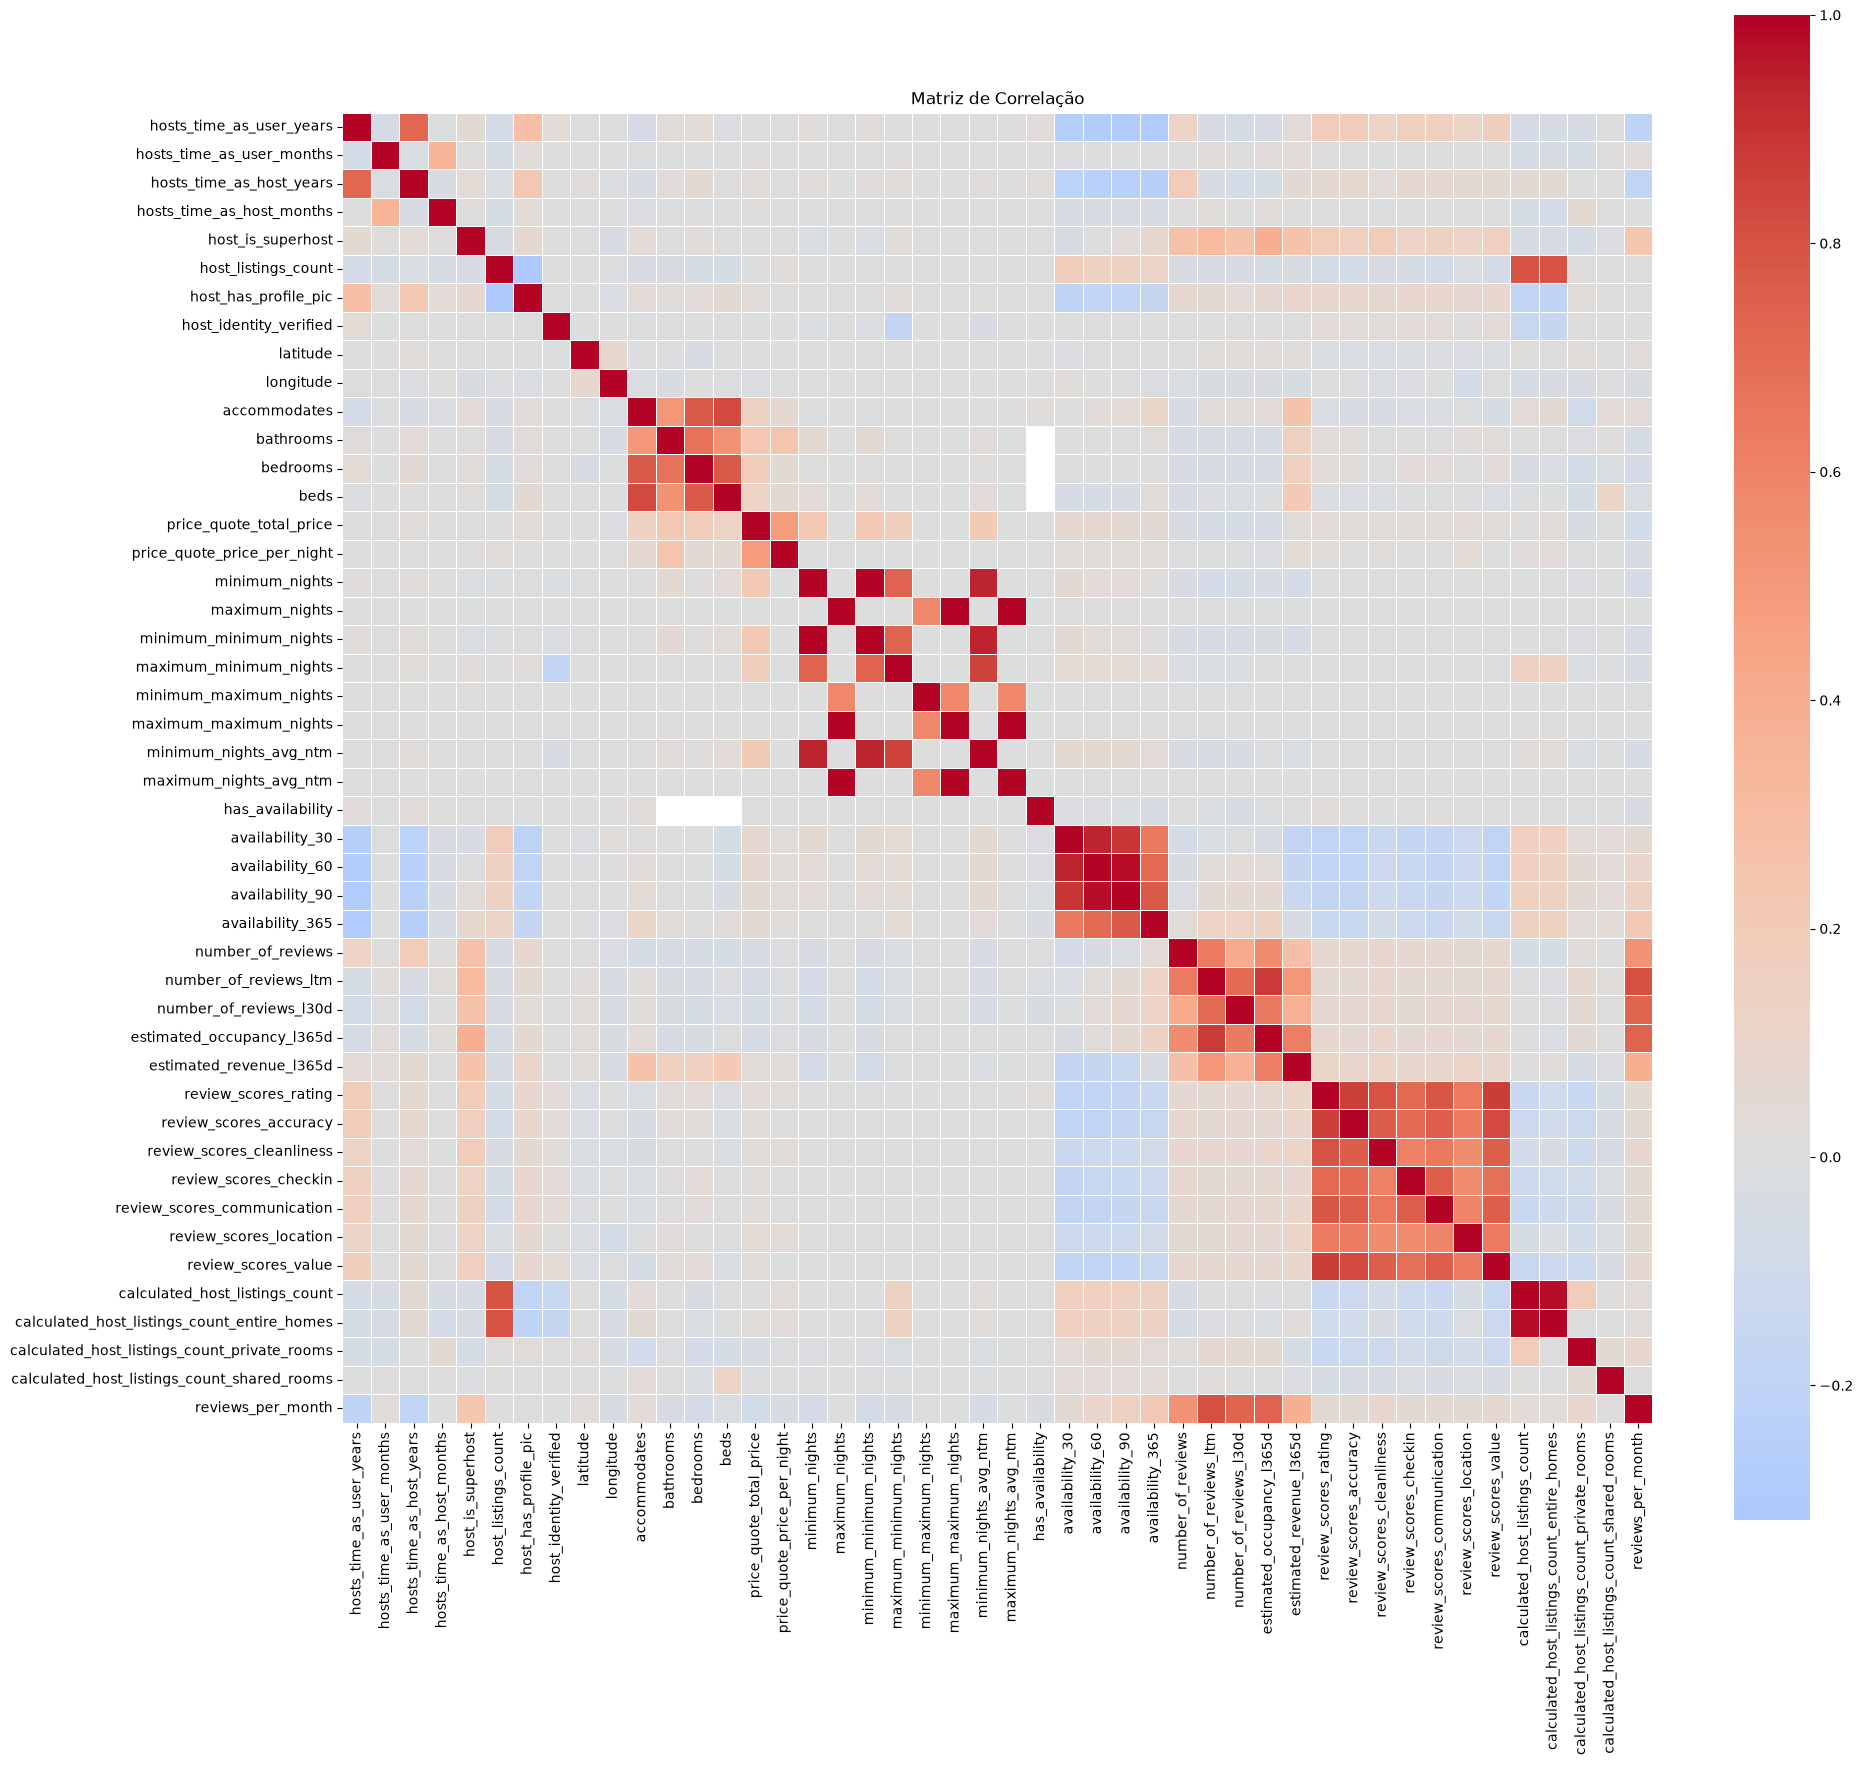

In [62]:
df_corr = df.copy()

bool_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability']
for col in bool_cols:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].map({'t': 1, 'f': 0})

df_numeric = df_corr.select_dtypes(include='number')

df_numeric = df_numeric.drop(columns=['id', 'host_id'], errors='ignore')

corr = df_numeric.corr()

corr_pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
).stack().reset_index()

corr_pairs.columns = ['Coluna 1', 'Coluna 2', 'Correlação']
corr_pairs['Módulo da correlação'] = corr_pairs['Correlação'].abs()

maiores_correlacoes = corr_pairs.sort_values(
    'Módulo da correlação', ascending=False
).head(10)

print(maiores_correlacoes.to_string(index=False))

plt.figure(figsize=(20, 18))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

                      Coluna 1                                    Coluna 2  Correlação  Módulo da correlação
                minimum_nights                      minimum_minimum_nights    1.000000              1.000000
                maximum_nights                      maximum_maximum_nights    1.000000              1.000000
         number_of_reviews_ltm                   estimated_occupancy_l365d    0.996218              0.996218
        maximum_maximum_nights                      maximum_nights_avg_ntm    0.984204              0.984204
                maximum_nights                      maximum_nights_avg_ntm    0.984204              0.984204
               availability_60                             availability_90    0.982030              0.982030
           host_listings_count              calculated_host_listings_count    0.967308              0.967308
        minimum_maximum_nights                      maximum_nights_avg_ntm    0.965016              0.965016
        maximum_min

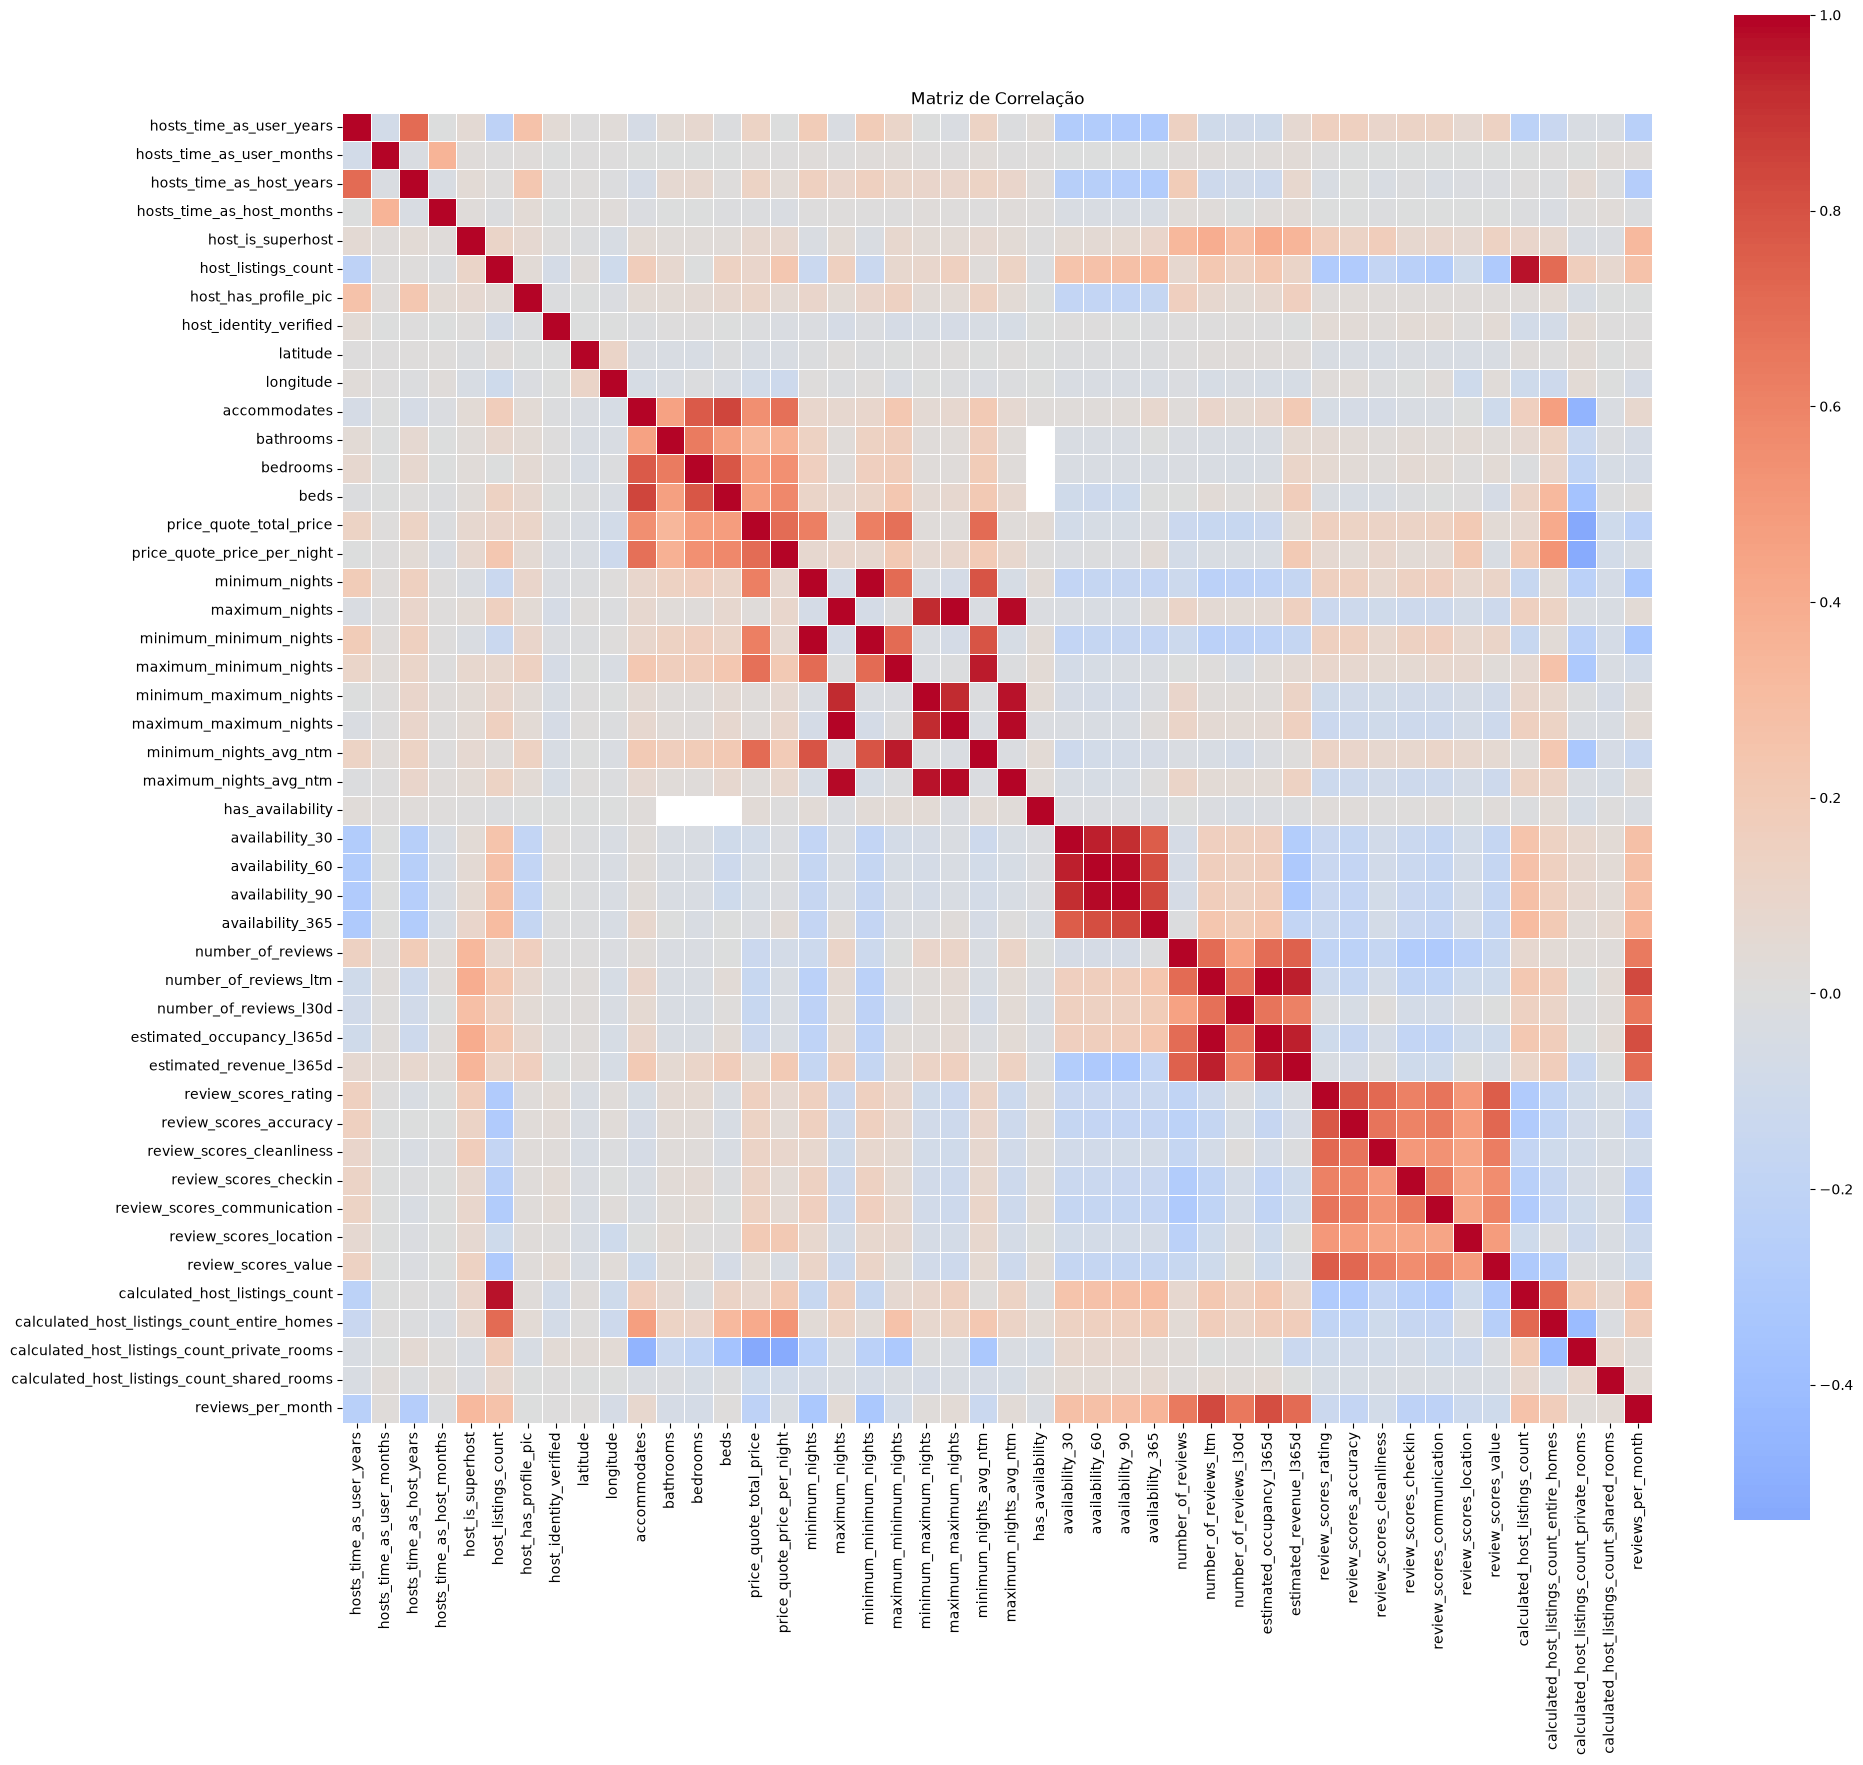

In [ ]:
df_corr = df.copy()

bool_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability']
for col in bool_cols:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].map({'t': 1, 'f': 0})

df_numeric = df_corr.select_dtypes(include='number')

df_numeric = df_numeric.drop(columns=['id', 'host_id'], errors='ignore')

corr = df_numeric.corr(method='spearman')

corr_pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
).stack().reset_index()

corr_pairs.columns = ['Coluna 1', 'Coluna 2', 'Correlação']
corr_pairs['Módulo da correlação'] = corr_pairs['Correlação'].abs()

maiores_correlacoes = corr_pairs.sort_values(
    'Módulo da correlação', ascending=False
).head(10)

print(maiores_correlacoes.to_string(index=False))

plt.figure(figsize=(20, 18))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

              Coluna 1                       Coluna 2  Correlação  Módulo da correlação
        minimum_nights         minimum_minimum_nights    1.000000              1.000000
        maximum_nights         maximum_maximum_nights    1.000000              1.000000
 number_of_reviews_ltm      estimated_occupancy_l365d    0.983165              0.983165
        maximum_nights         maximum_nights_avg_ntm    0.973850              0.973850
maximum_maximum_nights         maximum_nights_avg_ntm    0.973850              0.973850
minimum_maximum_nights         maximum_nights_avg_ntm    0.947476              0.947476
   host_listings_count calculated_host_listings_count    0.934073              0.934073
       availability_60                availability_90    0.923703              0.923703
        maximum_nights         minimum_maximum_nights    0.921354              0.921354
minimum_maximum_nights         maximum_maximum_nights    0.921354              0.921354


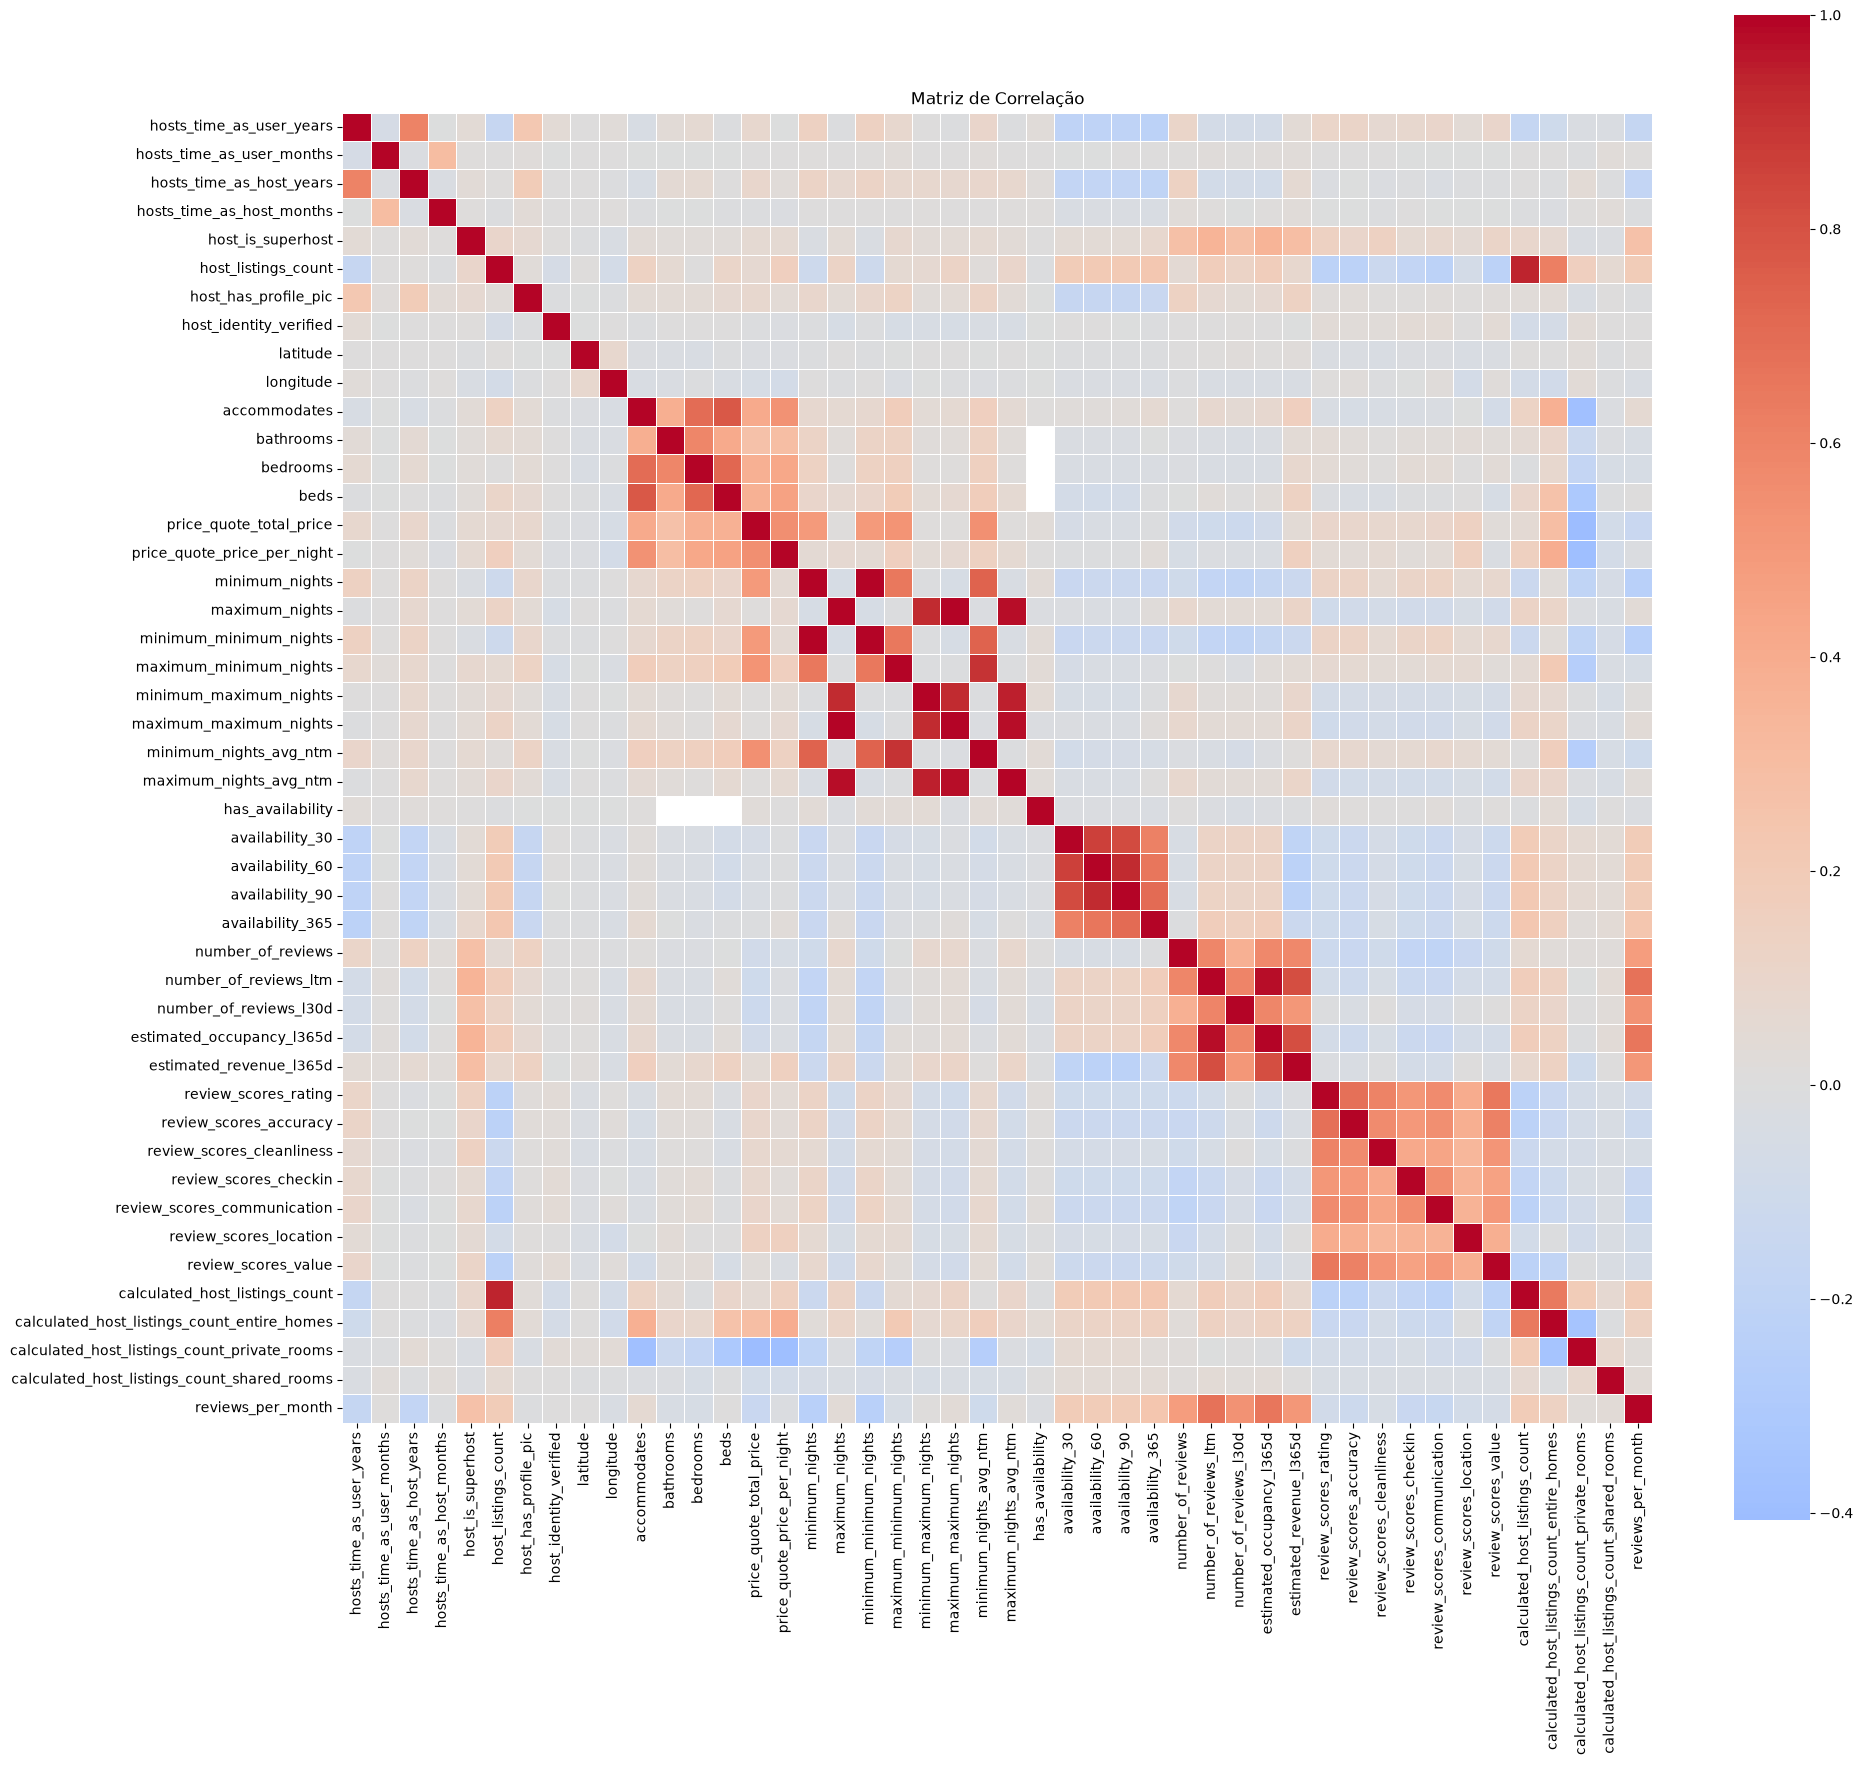

In [60]:
df_corr = df.copy()

bool_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability']
for col in bool_cols:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].map({'t': 1, 'f': 0})

df_numeric = df_corr.select_dtypes(include='number')

df_numeric = df_numeric.drop(columns=['id', 'host_id'], errors='ignore')

corr = df_numeric.corr(method='kendall')

corr_pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
).stack().reset_index()

corr_pairs.columns = ['Coluna 1', 'Coluna 2', 'Correlação']
corr_pairs['Módulo da correlação'] = corr_pairs['Correlação'].abs()

maiores_correlacoes = corr_pairs.sort_values(
    'Módulo da correlação', ascending=False
).head(10)

print(maiores_correlacoes.to_string(index=False))

plt.figure(figsize=(20, 18))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()